# Comparison of finite temperature with projective algorithm 

In this example we use the [pyALF](https://github.com/ALF-QMC/pyALF) to read the simulation data of a 4-site ring from the previous run from disk and plot them together. For further details, see Sec. 2.3 of [pyALF documentation](https://alf.physik.uni-wuerzburg.de/pyalf-doc/source/front.html).

---

**1.** Import `Simulation` class from the `py_alf` python module, which provides the interface with ALF, as well as numerical and plotting packages:

In [86]:
import matplotlib.pyplot as plt  # Plotting library

#
import numpy as np  # Numerical library
from py_alf import ALF_source, Simulation  # Interface with ALF
from py_alf.ana import load_res

alf_src = ALF_source(branch='main')    # Obtain ALF source code

Checking out branch main
Your branch is up to date with 'origin/main'.


Already on 'main'


 **2.** Create instances of `Simulation`, specifying the necessary parameters, in particular the `Projector` to `False` for finite T and `Projector` to `True` for projector

In [91]:
# Finite T
sims_finite_T = []                                # Vector of Simulation instances
for beta in [0.5, 1, 1.5, 3, 5, 10]:               # Values of Beta
    sim = Simulation(
        alf_src,
        'Hubbard',                       # Hamiltonian
        {                                # Model and simulation parameters for each Simulation instance
        'Model': 'Hubbard',              #    Base model
        'Lattice_type': 'N_leg_ladder',  #    Lattice type
        'L1': 4,                         #    Lattice length in the first unit vector direction
        'L2': 1,                         #    Lattice length in the second unit vector direction
        'Checkerboard': False,           #    Whether checkerboard decomposition is used or not
        'Symm': True,                    #    Whether symmetrization takes place
        'Projector': False,               #    Whether to use the projective algorithm
        'ham_T': 1.0,                    #    Hopping parameter
        'ham_U': 4.0,                    #    Hubbard interaction
        'ham_Tperp': 0.0,                #    For bilayer systems
        'beta': beta,                     #    Inverse temperature
        'Ltau': 0,                       #    '1' for time-displaced Green functions; '0' otherwise
        'NSweep': 600,                   #    Number of sweeps per bin
        'NBin': 50,                      #    Number of bins
        'Dtau': 0.05,                    #    Ltrot=beta/Dtau
        'Mz': True,                      #    If true, sets the M_z-Hubbard model: Nf=2, N_sum=1,
        },                               #             HS field couples to z-component of magnetization
    )
    sims_finite_T.append(sim)

# Projector
sims_projector = []
for theta in [0.1, 0.25, 0.5, 1.0, 2.0, 3.0]:               # Values of Theta
    sim = Simulation(
        alf_src,
        'Hubbard',                       # Hamiltonian
        {                                # Model and simulation parameters for each Simulation instance
        'Model': 'Hubbard',              #    Base model
        'Lattice_type': 'N_leg_ladder',  #    Lattice type
        'L1': 4,                         #    Lattice length in the first unit vector direction
        'L2': 1,                         #    Lattice length in the second unit vector direction
        'Checkerboard': False,           #    Whether checkerboard decomposition is used or not
        'Symm': True,                    #    Whether symmetrization takes place
        'Projector': True,               #    Whether to use the projective algorithm
        'Theta': theta,                  #    Projector parameter
        'ham_T': 1.0,                    #    Hopping parameter
        'ham_U': 4.0,                    #    Hubbard interaction
        'ham_Tperp': 0.0,                #    For bilayer systems
        'beta': 0.5,                     #    Inverse temperature
        'Ltau': 0,                       #    '1' for time-displaced Green functions; '0' otherwise
        'NSweep': 600,                   #    Number of sweeps per bin
        'NBin': 50,                      #    Number of bins
        'Dtau': 0.05,                    #    Ltrot=beta/Dtau
        'Mz': True,                      #    If true, sets the M_z-Hubbard model: Nf=2, N_sum=1,
        },                               #             HS field couples to z-component of magnetization
    )
    sims_projector.append(sim)

**3**. Read the simulation data from disk

In [99]:
%%capture

sims_list = [sims_finite_T, sims_projector]
dict_list = ['beta', 'Theta']
ener_list = []
values_list = []

for i, sims in enumerate(sims_list):
    ener = np.empty((len(sims), 2))          # Matrix for storing energy values
    values = np.empty((len(sims),))          # Matrix for betas or theta values, for plotting

    for k, sim in enumerate(sims):
        dir = sim.sim_dir
        obs = load_res(dir)

        values[k] = sim.sim_dict[dict_list[i]] 
        ener[k] = obs.iloc[0][['Ener_scal0', 'Ener_scal0_err']]  # Store energy value

    values_list.append(values)
    ener_list.append(ener)

Where the _cell magic_ `%%capture` suppresses the output of `load_res(dir)`, which lists the data directories.

**4**. Plot the internal energies for finite T and projector

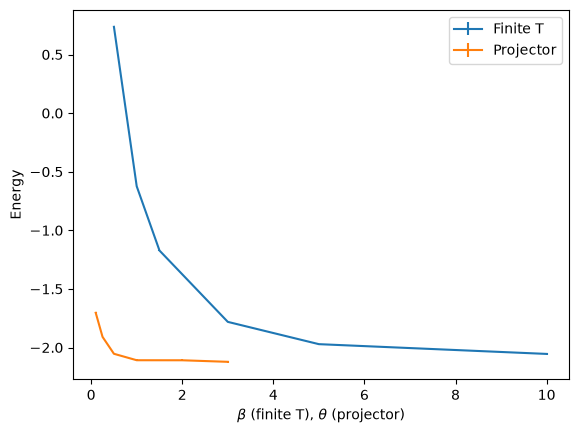

In [93]:
str_list = ['Finite T', 'Projector']

plt.xlabel(r'$\beta$ (finite T), $\theta$ (projector)')
plt.ylabel('Energy')
for i in range(len(ener_list)):
    plt.errorbar(values_list[i], ener_list[i][:, 0], ener_list[i][:, 1], label=str_list[i])

plt.legend()
# plt.xlim(0, 2.02);